# ESS 배터리 수명 예측 — 피처 설계와 구성 근거
울산 1반 U018 원종현

이 노트북은 DAY 1 EDA에서 세운 피처 설계를 실제 입력으로 옮긴다. **관측한 데이터 특성 → 후보 선정 이유 → 계산 정의 → 피처군 비교 계획** 순서로 설명한다. 예측 시점은 cycle 100이며, 셀 하나가 입력 테이블의 한 행이다.

DAY 1의 핵심 후보는 `dq_logvar`, `q2`, `q_slope_last`, `ir_delta`, `tmax_mean`, `i_high`의 6개다. 이들은 설계 단계의 후보이며 모두 최종 모델에 들어간다는 뜻은 아니다. 논문 방전 6피처는 별도 비교군으로 구성하고, 최종 모델·피처 선택과 성능 평가는 03_modeling에서 다룬다.

## 목차
1. EDA 발견과 피처 설계의 연결
2. 원본 데이터와 예측 시점
3. ΔQ 분산: 핵심 피처
4. 초기 용량·기울기: 용량 보조 피처
5. 저항·온도: 다른 측정 신호의 추가 가치
6. 고속 충전 비율: 전류 패턴 요약
7. 실제 데이터에서 후보의 관계·중복·결측 점검
8. 피처군 비교와 논문 피처
9. 타깃·분할·학습 내부 전처리
10. 확장 후보와 후속 모델링 입력

## 1. EDA 발견과 피처 설계의 연결

| EDA에서 확인한 내용 | 설계에 반영한 판단 | 구성할 피처 | 채택 여부 확인 방법 |
|---|---|---|---|
| Q3·Q5: ΔQ 분산과 수명은 전체뿐 아니라 배치 내부에서도 강한 음의 관계 | 가장 일관된 신호를 최소 기준선으로 사용 | `dq_logvar` | 단일 피처 기준 모델의 B1 내부 성능 |
| Q2: 초기 용량이 증가하는 셀이 93/118개이며 이후 가속 열화 | 초기 상태와 100사이클 근처의 변화를 나누어 표현 | `q2`, `q_slope_last` | ΔQ만 사용한 모델에 용량군 추가 시 이득 |
| Q5: Q2의 전체 상관은 배치 보정 후 거의 사라짐 | 초기 용량은 확정 핵심이 아닌 보조 후보 | `q2` | 배치 차이의 대리 변수가 아닌 추가 신호인지 검증 |
| Q5: ΔQ 통계의 중복·공선성, IR 6셀 결측, 온도 신호는 약함 | 서로 다른 측정 정보를 작은 후보군으로 비교 | `ir_delta`, `tmax_mean` | 용량군 대비 저항·온도군의 추가 가치 |
| Q4: 최대 C-rate만으로 수명 설명이 어렵고 배치별 관계도 다름 | 한 순간의 최고 전류 대신 고속 구간의 시간 비중 사용 | `i_high` | 용량·저항·온도 5개 피처군 대비 충전 패턴의 추가 가치 |
| Q2: Knee와 후기 기울기는 전체 수명 궤적을 사용 | 예측 시점에 알 수 없는 정보 제거 | Knee·후기 기울기 등 제외 | 입력 열 whitelist와 시간 범위 검사 |

상관이 약한 후보를 포함한 것은 성능 향상을 이미 확인했기 때문이 아니다. 다른 측정 신호가 ΔQ만으로 설명하지 못한 부분을 보완하는지 확인하기 위한 가설이다. 약한 후보는 B1 내부 검증에서 추가 가치가 없으면 제외한다.

In [1]:
from pathlib import Path
import os
import re
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, pearsonr
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
DATA = Path(os.environ.get('BATTERY_DATA_DIR', ROOT / 'data/raw'))
CACHE = ROOT / '.cache/features'
CACHE.mkdir(parents=True, exist_ok=True)
FILES = {
    'B1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'B2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'B3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
CORE6 = ['dq_logvar', 'q2', 'q_slope_last', 'ir_delta', 'tmax_mean', 'i_high']
from matplotlib import font_manager
font = Path('/System/Library/Fonts/AppleSDGothicNeo.ttc')
if font.exists():
    font_manager.fontManager.addfont(str(font))
plt.rcParams.update({'font.family': ['DejaVu Sans', 'Apple SD Gothic Neo'],
                     'axes.unicode_minus': False, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'B1': '#167c80', 'B2': '#dd7745', 'B3': '#6162aa'}
FIGURES = ROOT / 'results/figures'
FIGURES.mkdir(parents=True, exist_ok=True)


## 2. 원본 데이터와 예측 시점

01_EDA와 같은 원본 MAT 및 채택 기준을 사용한다. 수명 라벨은 타깃으로만 보관하고, 실제 피처 계산에 필요한 summary는 **cycle 2–100**, Q(V)·충전 시계열은 **cycle 10·100**에서 먼저 잘라서 읽는다. 전체 수명 궤적을 피처 함수에 넘기지 않는다.

라벨 품질 점검에 사용한 종료 용량은 분석 대상을 정하기 위한 정보이며 모델의 입력이 아니다. 0 이하의 IR은 결측, 용량 0 이하 또는 1.3 Ah 초과는 해당 용량 통계에서 마스킹한다. 사이클 번호를 재부여하지 않는다.

In [2]:
metadata = []
cells = {}
for batch, filename in FILES.items():
    with h5py.File(DATA / filename, 'r') as f:
        b = f['batch']
        for index in range(len(b['summary'])):
            cell = f'{batch}-C{index + 1:02d}'
            s = f[b['summary'][index, 0]]
            life = float(np.asarray(f[b['cycle_life'][index, 0]]).item())
            q_end = np.asarray(s['QDischarge']).ravel()[-1]
            if not np.isfinite(life) or q_end > .885 or cell == 'B3-C38':
                continue
            policy = ''.join(chr(int(v)) for v in np.asarray(f[b['policy_readable'][index, 0]]).ravel())
            cycle = np.asarray(s['cycle'], dtype=float).ravel()
            assert np.array_equal(cycle[:100], np.arange(1, 101))
            early = (cycle >= 2) & (cycle <= 100)
            summary = {key: np.asarray(s[key], dtype=float).ravel()[early] for key in s}
            cycle_group = f[b['cycles'][index, 0]]
            voltage = np.asarray(f[b['Vdlin'][index, 0]], dtype=float).ravel()
            curves = {number: np.asarray(f[cycle_group['Qdlin'][number - 1, 0]], dtype=float).ravel()
                      for number in [10, 100]}
            charge = {
                number: {key: np.asarray(f[cycle_group[key][number - 1, 0]], dtype=float).ravel()
                         for key in ['t', 'I', 'Qc']}
                for number in [10, 100]
            }
            delta = curves[100] - curves[10]
            assert len(voltage) == len(delta) == 1000 and np.isfinite(delta).all()
            cells[cell] = {'summary': summary, 'v': voltage, 'q10': curves[10],
                           'q100': curves[100], 'dq': delta, 'charge': charge}
            metadata.append({'cell': cell, 'batch': batch, 'policy': policy, 'life': life})
d = pd.DataFrame(metadata)
assert d.groupby('batch').size().to_dict() == {'B1': 36, 'B2': 39, 'B3': 43}
assert all(np.max(c['summary']['cycle']) <= 100 for c in cells.values())
display(d.groupby('batch').agg(cells=('cell', 'size'), min_life=('life', 'min'), max_life=('life', 'max')))

,cells,min_life,max_life
batch,,,
B1,36,534.0,1074.0
B2,39,392.0,1186.0
B3,43,541.0,1935.0


## 3. ΔQ 분산: 핵심 피처

### 곡선의 국소 변화를 하나의 수치로 요약
Q3에서 단수명 셀은 Q100−Q10 곡선의 음의 변화와 굴곡이 큰 경향을 보였다. 분산은 전압에 따라 변화량이 얼마나 달라지는지 요약한다. 전압점 1,000개를 독립 셀 1,000개로 취급하는 것이 아니라 **하나의 셀의 곡선을 하나의 피처로 압축**한다.

`dq_logvar = log10(Var(Q100(V) − Q10(V), ddof=1))`

분산 계산 전 단위는 Ah²다. 로그 변환은 작은 분산값의 자릿수 차이를 압축해 log 수명과의 관계를 선형 모델로 검토하기 위한 선택이다. 모델의 입력 표준화와는 별도 변환이다.

전체 Spearman ρ≈−0.885, 배치 내부 −0.826/−0.709/−0.787, 배치 보정 후 ≈−0.835였다. 따라서 전체 상관만 강한 Q2와 달리 최소 기준선으로 우선 채택한다.

In [3]:
dq_rows = []
for cell, c in cells.items():
    delta = c['q100'] - c['q10']
    variance = np.var(delta, ddof=1)
    dq_rows.append({
        'cell': cell, 'dq_logvar': np.log10(max(variance, 1e-20)),
        'dq_logstd': np.log10(max(np.std(delta, ddof=1), 1e-20)),
        'dq_logabsmin': np.log10(max(abs(delta.min()), 1e-20)),
        'dq_mean': delta.mean(), 'dq_skew': skew(delta, bias=False),
        'dq_kurtosis': kurtosis(delta, bias=False),
    })
d = d.merge(pd.DataFrame(dq_rows), on='cell', validate='one_to_one')
display(d[['cell', 'dq_logvar']].head())
assert np.allclose(d.dq_logstd, .5 * d.dq_logvar)

,cell,dq_logvar
0,B1-C06,-4.178443
1,B1-C07,-3.768443
2,B1-C08,-3.813052
3,B1-C10,-4.058949
4,B1-C12,-4.146462


### ΔQ 곡선에서 분산 피처로

왼쪽은 같은 Batch 2의 최단·최장수명 셀을 예시로 골라 ΔQ 곡선과 log 분산을 함께 표시한다. 오른쪽은 118셀 전체를 배치별로 구분해 핵심 신호의 관계를 확인한다. 두 예시만으로 집단 전체의 차이를 판단하지 않는다.

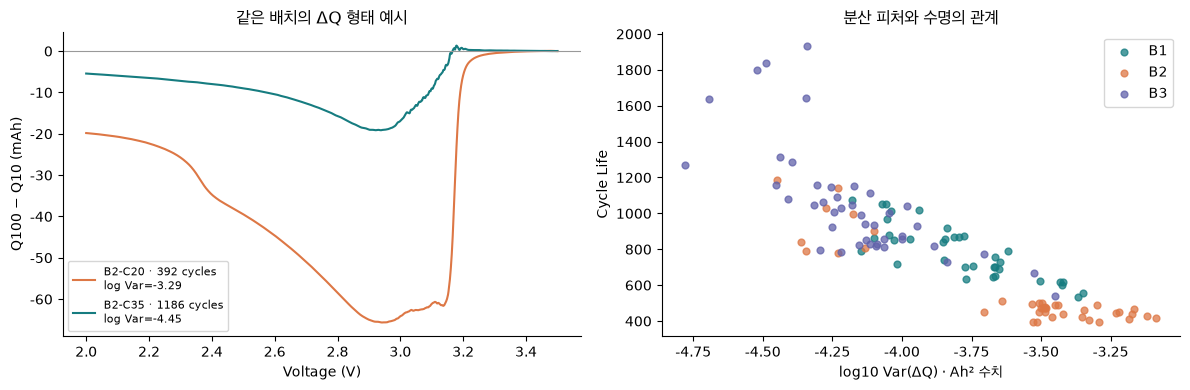

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
b2 = d[d.batch == 'B2']
examples = [('최단수명 예시', b2.loc[b2.life.idxmin()], '#dd7745'),
            ('최장수명 예시', b2.loc[b2.life.idxmax()], '#167c80')]
for label, row, color in examples:
    cell = cells[row.cell]
    axes[0].plot(cell['v'], cell['dq'] * 1000, color=color,
                 label=f'{row.cell} · {row.life:.0f} cycles\nlog Var={row.dq_logvar:.2f}')
axes[0].axhline(0, color='#999', linewidth=.8)
axes[0].set(title='같은 배치의 ΔQ 형태 예시', xlabel='Voltage (V)', ylabel='Q100 − Q10 (mAh)')
axes[0].legend(fontsize=8)
for batch, group in d.groupby('batch'):
    axes[1].scatter(group.dq_logvar, group.life, color=COLORS[batch], label=batch, s=24, alpha=.75)
axes[1].set(title='분산 피처와 수명의 관계', xlabel='log10 Var(ΔQ) · Ah² 수치', ylabel='Cycle Life')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / 'fe_deltaq_signal.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

log 표준편차는 log 분산의 정확한 0.5배다. 같은 정보를 두 번 입력하므로 기본 후보에서 제외한다. 최솟값·평균·왜도·첨도는 대체 후보로 남기되, 분산과의 중복을 확인하고 별도 피처군으로 비교한다.

## 4. 초기 용량·기울기: 용량 보조 피처

### Qd(2): 초기 상태의 기준값
cycle 1에는 Qd=0인 기록이 있어 정상 초기 용량으로 사용하지 않는다. `q2`는 cycle 2의 방전 용량(Ah)으로 초기 상태를 표현한다.

Q2와 수명의 전체 상관은 −0.563이지만 배치 보정 후 +0.011로 거의 사라졌다. 따라서 높은 초기 용량이 긴 수명을 보장한다고 해석하지 않는다. ΔQ 변화를 해석할 때 초기 상태가 추가 정보를 주는지 검증할 **보조 후보**다.

### cycle 91–100 기울기: 예측 시점 근처의 국소 변화
Q2에서 초기 용량 증가와 후기 가속이 함께 관찰됐다. 전체 초기 구간의 단일 기울기는 증가·감소를 평균낼 수 있어, 100사이클 직전 10개 관측의 기울기를 추가한다. 단위는 Ah/cycle이며 음수는 감소, 양수는 증가를 나타낸다.

이 기울기를 전체 수명으로 직선 외삽하지 않는다. 배치 보정 상관은 약 +0.308이지만 B3 내부 관계는 약 +0.035로 약하다. 배치마다 추가 가치가 다를 수 있어 용량군의 성능 개선을 확인한다.

In [5]:
def slope(x, y):
    mask = np.isfinite(x) & np.isfinite(y)
    return float(np.polyfit(x[mask], y[mask], 1)[0]) if mask.sum() >= 3 else np.nan

capacity_rows = []
for cell, c in cells.items():
    s = c['summary']
    x = s['cycle']
    q = s['QDischarge'].copy()
    q[(q <= 0) | (q > 1.3)] = np.nan
    q2 = q[x == 2][0]
    q100 = q[x == 100][0]
    late_initial = (x >= 91) & (x <= 100)
    initial = (x >= 10) & (x <= 100)
    capacity_rows.append({
        'cell': cell, 'q2': q2, 'q100': q100, 'q_ratio': q100 / q2,
        'q_slope_last': slope(x[late_initial], q[late_initial]),
        'q_slope': slope(x[initial], q[initial]),
    })
d = d.merge(pd.DataFrame(capacity_rows), on='cell', validate='one_to_one')
display(d[['cell', 'q2', 'q_slope_last']].head())

,cell,q2,q_slope_last
0,B1-C06,1.076127,-0.000023
1,B1-C07,1.075836,-0.000062
2,B1-C08,1.093864,-0.000041
3,B1-C10,1.082974,-0.000013
4,B1-C12,1.053779,-0.000012


### 초기 상태와 100사이클 직전 변화를 구분

B1에서 수명이 중앙값에 가장 가까운 셀을 예시로 사용한다. 왼쪽 점은 Q2, 음영은 91–100 구간이다. 오른쪽은 그 구간만 확대해 기울기 계산을 보여주며, 작은 변화를 읽기 쉽게 mAh로 표시한다. 이 국소 기울기는 전체 수명의 외삽선이 아니다.

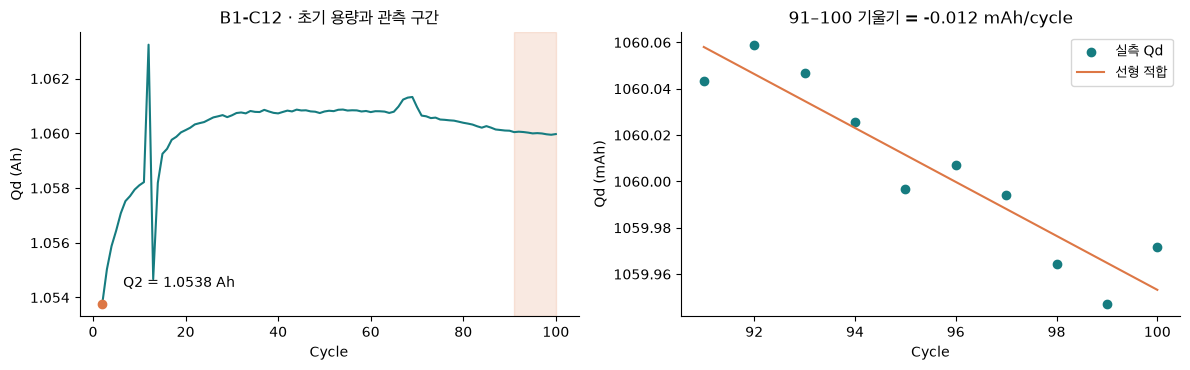

In [6]:
b1 = d[d.batch == 'B1']
row = b1.loc[(b1.life - b1.life.median()).abs().idxmin()]
s = cells[row.cell]['summary']
x, q = s['cycle'], s['QDischarge'].copy()
q[(q <= 0) | (q > 1.3)] = np.nan
window = (x >= 91) & (x <= 100)
fit = np.polyfit(x[window], q[window], 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(x, q, color=COLORS['B1'])
axes[0].scatter([2], [row.q2], color='#dd7745', zorder=3)
axes[0].annotate(f'Q2 = {row.q2:.4f} Ah', xy=(2, row.q2), xytext=(15, 12), textcoords='offset points')
axes[0].axvspan(91, 100, color='#dd7745', alpha=.16)
axes[0].set(title=f'{row.cell} · 초기 용량과 관측 구간', xlabel='Cycle', ylabel='Qd (Ah)')
axes[1].scatter(x[window], q[window] * 1000, color=COLORS['B1'], label='실측 Qd')
axes[1].plot(x[window], np.polyval(fit, x[window]) * 1000, color='#dd7745', label='선형 적합')
axes[1].set(title=f'91–100 기울기 = {row.q_slope_last * 1000:.3f} mAh/cycle', xlabel='Cycle', ylabel='Qd (mAh)')
axes[1].ticklabel_format(axis='y', style='plain', useOffset=False)
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / 'fe_capacity_windows.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## 5. 저항·온도: 다른 측정 신호의 추가 가치

### IR(100)−IR(10): 저항 변화
ΔQ와 용량만으로 표현되지 않는 초기 저항의 변화를 요약한다. 절대 저항 대신 두 시점의 차이를 사용하며 단위는 Ω다. 실제 관측 관계는 B1/B2/B3에서 −0.271/+0.122/−0.320으로 일관적이지 않다. 저항 증가가 반드시 단수명을 설명한다는 결론이 아니라, 별도 측정 신호의 추가 가치를 확인하는 후보로 구성했다.

B2-C42~C47의 6셀은 IR이 유효하지 않다. IR 결측 때문에 수명 라벨이 있는 셀을 삭제하지 않고, 학습 fold에서만 중앙값 대치한다.

### 평균 Tmax(2–100): 초기 열적 조건
순간 최고값 한 개보다 초기 구간의 대표적인 최대 온도를 평균해 표현한다. 단위는 °C다. 배치별 수명 상관은 약 −0.102/−0.136/−0.054로 약하다. ΔQ·용량과 다른 열적 정보를 제공할 가능성 때문에 후보로 두되, 성능 개선이 없으면 제외한다.

원시 시간축의 큰 간격에 민감한 온도 적분은 원인을 확인하지 못해 기본 후보에 넣지 않는다. 온도 평균이 수명과 인과적으로 연결된다는 주장도 하지 않는다.

In [7]:
sensor_rows = []
for cell, c in cells.items():
    s = c['summary']
    x = s['cycle']
    ir = s['IR'].copy()
    ir[(ir <= 0) | ~np.isfinite(ir)] = np.nan
    values = {'cell': cell, 'ir_delta': ir[x == 100][0] - ir[x == 10][0]}
    for source, output in [('IR', 'ir_mean'), ('Tmax', 'tmax_mean'),
                           ('Tavg', 'tavg_mean'), ('chargetime', 'charge_time')]:
        values_in_window = s[source]
        valid = np.isfinite(values_in_window) & (values_in_window > 0)
        values[output] = values_in_window[valid].mean() if valid.any() else np.nan
    values['temp_span'] = np.nanmean(s['Tmax'] - s['Tmin'])
    sensor_rows.append(values)
d = d.merge(pd.DataFrame(sensor_rows), on='cell', validate='one_to_one')
display(d[['cell', 'ir_delta', 'tmax_mean']].head())
display(d.loc[d.ir_delta.isna(), ['cell', 'batch', 'life']])
assert d.ir_delta.isna().sum() == 6

,cell,ir_delta,tmax_mean
0,B1-C06,0.000077,33.020007
1,B1-C07,-0.000022,35.792631
2,B1-C08,0.000091,35.322695
3,B1-C10,0.000097,35.984934
4,B1-C12,0.000075,36.231754


,cell,batch,life
69,B2-C42,B2,442.0
70,B2-C43,B2,474.0
71,B2-C44,B2,1029.0
72,B2-C45,B2,841.0
73,B2-C46,B2,997.0
74,B2-C47,B2,503.0


### 저항·온도 신호의 배치별 관계

점이 뚜렷한 한 방향으로 모이는지, 배치별 방향이 같은지 확인한다. 저항 변화는 가독성을 위해 그래프에서만 mΩ로 표시하며 실제 피처 단위는 Ω다. IR 결측 6셀은 왼쪽 산점도에 표시되지 않는다.

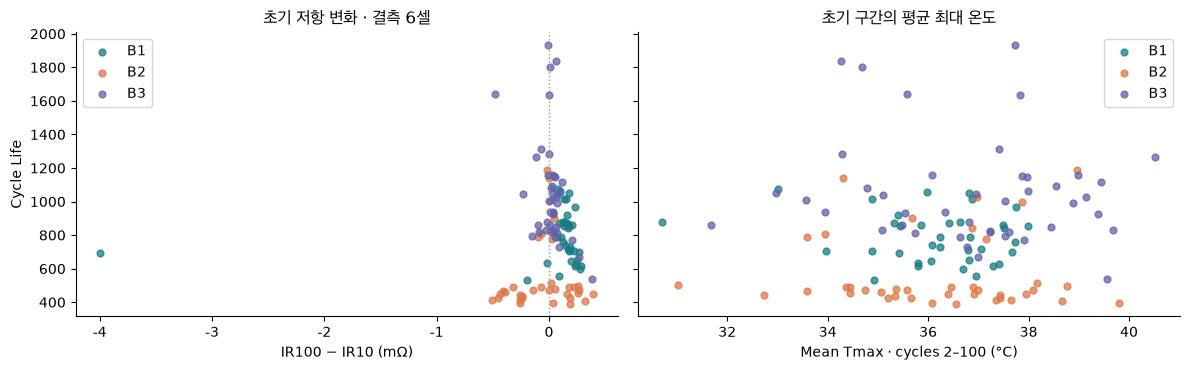

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for batch, group in d.groupby('batch'):
    axes[0].scatter(group.ir_delta * 1000, group.life, color=COLORS[batch], label=batch, s=24, alpha=.75)
    axes[1].scatter(group.tmax_mean, group.life, color=COLORS[batch], label=batch, s=24, alpha=.75)
axes[0].axvline(0, color='#999', linestyle=':', linewidth=1)
axes[0].set(title='초기 저항 변화 · 결측 6셀', xlabel='IR100 − IR10 (mΩ)', ylabel='Cycle Life')
axes[1].set(title='초기 구간의 평균 최대 온도', xlabel='Mean Tmax · cycles 2–100 (°C)')
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'fe_sensor_signals.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## 6. 고속 충전 비율: 전류 패턴 요약

### 최고 전류 대신 5C 초과 구간의 시간 비율
Q4에서 최대 C-rate가 같아도 전환 SOC와 적용 구간이 다른 정책의 수명이 달랐다. 따라서 “얼마나 높은 전류였나”와 함께 “고속 구간이 얼마나 오래 지속됐나”를 표현한다.

각 cycle 10·100에서 인접 측정점의 전류·충전 용량을 평균하고, `I>0.05C`, `Qc≤0.88Ah`, `Δt>0`인 충전 구간만 사용한다. 5C를 초과한 구간의 시간 합을 유효 충전 시간으로 나눈 뒤 두 사이클의 비율을 평균한다. 무차원 비율(0–1)이며, 단순 측정점 개수 비율은 불규칙한 샘플 간격에 영향을 받으므로 사용하지 않는다.

5C는 고속 구간을 요약하기 위해 설계 단계에서 정한 임계값이지, 이 데이터로 검증된 최적 임계값이나 안전 한계가 아니다. B3 내부 ρ≈−0.191, 배치 보정 ρ≈−0.138로 약한 후보다. Core5 대비 추가 기여가 있을 때만 채택한다. 원본 I는 이미 C-rate여서 1.1로 다시 나누지 않는다.

In [9]:
current_rows = []
for cell, c in cells.items():
    cycle_stats = []
    for number in [10, 100]:
        charge = c['charge'][number]
        dt = np.diff(charge['t'])
        rates = (charge['I'][:-1] + charge['I'][1:]) / 2
        qc_mid = (charge['Qc'][:-1] + charge['Qc'][1:]) / 2
        mask = (np.isfinite(dt) & np.isfinite(rates) & np.isfinite(qc_mid)
                & (dt > 0) & (rates > .05) & (qc_mid <= .88))
        if not mask.any():
            cycle_stats.append([np.nan] * 5)
            continue
        weights, rates = dt[mask], rates[mask]
        average = np.average(rates, weights=weights)
        cycle_stats.append([
            average, np.sqrt(np.average((rates - average)**2, weights=weights)),
            weights[rates > 5].sum() / weights.sum(), rates.max(), weights.sum(),
        ])
    values = np.nanmean(cycle_stats, axis=0)
    current_rows.append(dict(cell=cell, **dict(zip(['i_mean', 'i_std', 'i_high', 'i_peak', 'i_duration'], values))))
d = d.merge(pd.DataFrame(current_rows), on='cell', validate='one_to_one')
assert d.i_high.between(0, 1).all()
display(d[['cell', 'i_high', 'i_mean', 'i_duration']].head())

,cell,i_high,i_mean,i_duration
0,B1-C06,0.000000,4.397077,10.916696
1,B1-C07,0.000000,4.796536,10.007498
2,B1-C08,0.000000,4.796510,10.007752
3,B1-C10,0.399003,4.312229,11.126426
4,B1-C12,0.479918,4.148846,11.567391


### 고속 충전의 크기와 지속시간

왼쪽은 B1에서 i_high가 50%에 가장 가까운 셀의 cycle 10 충전 구간을 보여준다. 5C 초과 구간을 색칠해 시간 비율이 무엇을 요약하는지 확인한다. 그래프의 시간은 유효 충전 구간의 Δt를 누적한 값이며 원시 시계열의 휴지 시간은 제외한다. 오른쪽 피처는 cycle 10·100 비율의 평균이다.

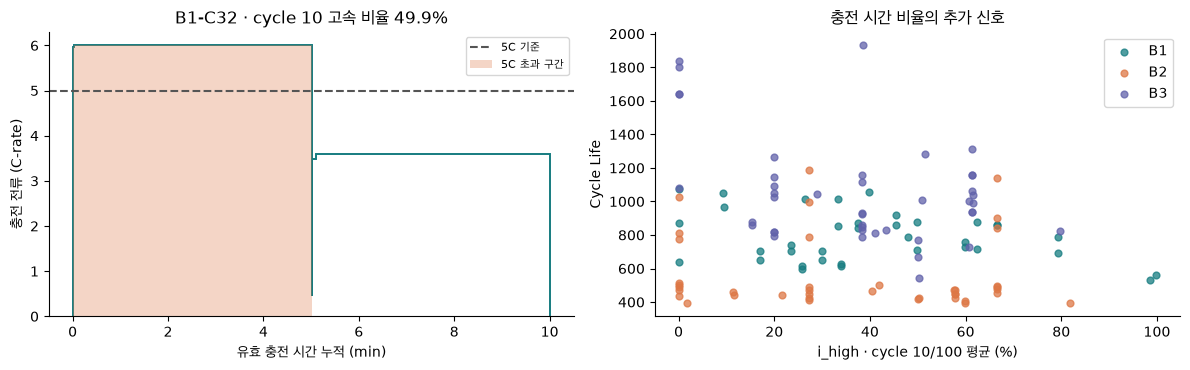

In [10]:
row = d.loc[(d[d.batch == 'B1'].i_high - .5).abs().idxmin()]
charge = cells[row.cell]['charge'][10]
dt = np.diff(charge['t'])
rates = (charge['I'][:-1] + charge['I'][1:]) / 2
qc = (charge['Qc'][:-1] + charge['Qc'][1:]) / 2
mask = np.isfinite(dt) & np.isfinite(rates) & np.isfinite(qc) & (dt > 0) & (rates > .05) & (qc <= .88)
weights, rates = dt[mask], rates[mask]
edges = np.r_[0, np.cumsum(weights)]
fraction10 = weights[rates > 5].sum() / weights.sum()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].stairs(rates, edges, color=COLORS['B1'], linewidth=1.4)
axes[0].bar(edges[:-1][rates > 5], rates[rates > 5], width=weights[rates > 5],
            align='edge', color='#dd7745', alpha=.3, label='5C 초과 구간')
axes[0].axhline(5, color='#555', linestyle='--', label='5C 기준')
axes[0].set(title=f'{row.cell} · cycle 10 고속 비율 {fraction10:.1%}',
            xlabel='유효 충전 시간 누적 (min)', ylabel='충전 전류 (C-rate)')
axes[0].legend(fontsize=8)
for batch, group in d.groupby('batch'):
    axes[1].scatter(group.i_high * 100, group.life, color=COLORS[batch], label=batch, s=24, alpha=.75)
axes[1].set(title='충전 시간 비율의 추가 신호', xlabel='i_high · cycle 10/100 평균 (%)', ylabel='Cycle Life')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURES / 'fe_charge_duration.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## 7. 실제 데이터에서 후보의 관계·중복·결측 점검

### 여섯 후보의 정의와 판단 기준
| 피처 | 관측 구간·단위 | 구성한 이유 | 설계 단계의 지위 |
|---|---|---|---|
| `dq_logvar` | Q100−Q10 · log10(Ah² 수치) | 배치 내부에서도 일관된 ΔQ 형태 변화 | 핵심 기준선 |
| `q2` | cycle 2 · Ah | 초기 상태의 기준값 | 배치 효과를 확인할 보조 후보 |
| `q_slope_last` | cycle 91–100 · Ah/cycle | 예측 시점 직전의 국소 용량 변화 | 용량군의 추가 가치 확인 |
| `ir_delta` | cycle 100−10 · Ω | 다른 센서의 초기 변화 | 결측·배치 차이 고려 |
| `tmax_mean` | cycle 2–100 · °C | 초기 열적 조건 | 약한 관계, 개선 시에만 채택 |
| `i_high` | cycle 10·100 · 0–1 비율 | 고속 충전 구간의 시간 비중 | 약한 관계, 개선 시에만 채택 |

아래 코드는 원본에서 계산한 후보로 EDA의 상관과 VIF를 다시 확인한다. 이 점검은 피처 정의·설계 근거를 확인하는 절차이며, 전체 배치의 상관이나 VIF를 기준으로 최종 피처를 선택하지 않는다.

In [11]:
correlation_table = []
for batch, group in [('ALL', d), *list(d.groupby('batch'))]:
    for feature in CORE6:
        valid = group[[feature, 'life']].dropna()
        correlation_table.append({'batch': batch, 'feature': feature,
                                  'rho': valid[feature].corr(valid.life, method='spearman'), 'n': len(valid)})
correlations = pd.DataFrame(correlation_table).pivot(index='feature', columns='batch', values='rho')
for feature in CORE6:
    valid = d[[feature, 'life', 'batch']].dropna()
    ranks = valid[[feature, 'life']].rank()
    residual = ranks - ranks.groupby(valid.batch).transform('mean')
    correlations.loc[feature, 'batch_adjusted'] = residual[feature].corr(residual.life)
display(correlations.reindex(CORE6))
display(d[CORE6].isna().sum().rename('missing'))
display(d[CORE6].describe().T)

z = d[CORE6].dropna()
z = (z - z.mean()) / z.std()
vif_rows = []
for feature in CORE6:
    target = z[feature].to_numpy()
    predictors = z.drop(columns=feature).to_numpy()
    fitted = predictors @ np.linalg.lstsq(predictors, target, rcond=None)[0]
    r2 = 1 - np.sum((target - fitted)**2) / np.sum(target**2)
    vif_rows.append({'feature': feature, 'vif': 1 / (1 - r2), 'complete_cells': len(z)})
display(pd.DataFrame(vif_rows))

batch,ALL,B1,B2,B3,batch_adjusted
feature,,,,,
dq_logvar,-0.885054,-0.826232,-0.708979,-0.786982,-0.834695
q2,-0.562734,0.161025,0.084928,0.183946,0.010673
q_slope_last,-0.000307,0.320762,0.354084,0.034584,0.307888
ir_delta,-0.097351,-0.270691,0.121835,-0.319641,-0.172557
tmax_mean,0.057703,-0.102458,-0.135945,-0.053689,-0.060444
i_high,-0.097718,-0.121926,-0.112434,-0.190509,-0.137752


dq_logvar       0
q2              0
q_slope_last    0
ir_delta        6
tmax_mean       0
i_high          0
Name: missing, dtype: int64

,count,mean,std,min,25%,50%,75%,max
dq_logvar,118.0,-3.865446,0.389353,-4.778946,-4.167336,-3.911357,-3.505028,-3.085447
q2,118.0,1.078018,0.014892,1.046273,1.067472,1.075508,1.090594,1.109278
q_slope_last,118.0,-0.000042,0.000107,-0.000437,-0.000064,-0.000039,-0.000013,0.000238
ir_delta,112.0,0.000006,0.000423,-0.003995,-0.000011,0.000052,0.000172,0.000394
tmax_mean,118.0,36.397539,1.819015,30.709141,35.342696,36.734735,37.590055,40.524259
i_high,118.0,0.377863,0.241763,0.000000,0.199442,0.383924,0.598963,0.998267


,feature,vif,complete_cells
0,dq_logvar,2.214889,112
1,q2,2.259738,112
2,q_slope_last,1.159590,112
3,ir_delta,1.032041,112
4,tmax_mean,1.148571,112
5,i_high,1.150408,112


### 후보의 강도·중복·결측을 한눈에 비교

왼쪽은 수명 상관의 배치 일관성, 가운데는 Core6의 피처 간 중복, 오른쪽은 결측 위치를 보여준다. 파랑·빨강은 상관의 부호이고 진하기는 절댓값이다. 이 그림은 후보 진단이며 최종 채택은 B1 내부 성능 비교로 결정한다.

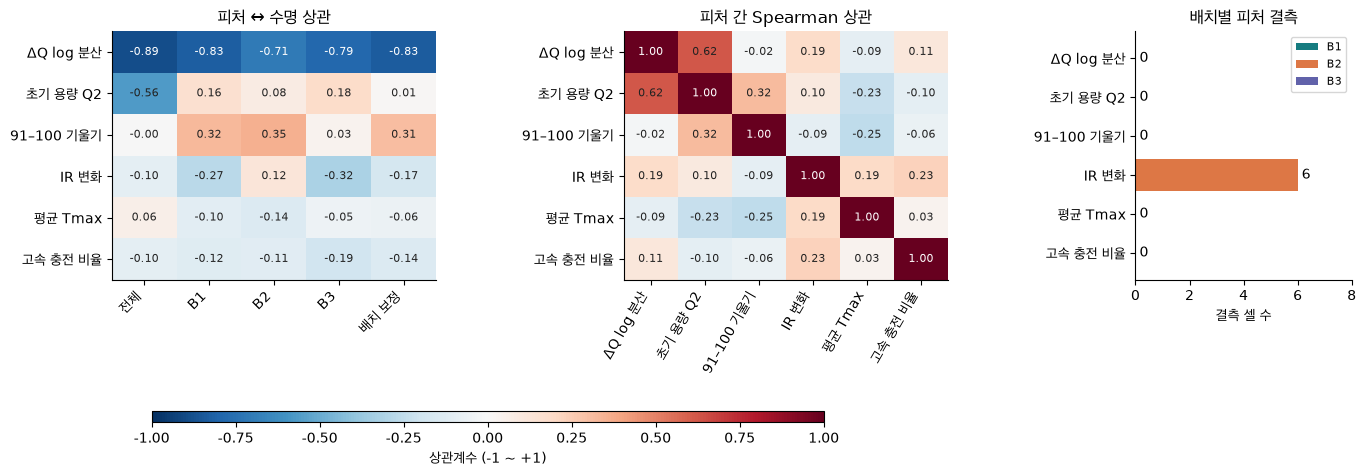

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={'width_ratios': [1.2, 1.2, .8]})
labels = ['ΔQ log 분산', '초기 용량 Q2', '91–100 기울기', 'IR 변화', '평균 Tmax', '고속 충전 비율']
columns = ['ALL', 'B1', 'B2', 'B3', 'batch_adjusted']
target_corr = correlations.reindex(index=CORE6, columns=columns).to_numpy()
feature_corr = d[CORE6].corr(method='spearman').to_numpy()
for ax, values, title in [(axes[0], target_corr, '피처 ↔ 수명 상관'), (axes[1], feature_corr, '피처 간 Spearman 상관')]:
    im = ax.imshow(values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_yticks(range(6), labels)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f'{values[i, j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(values[i, j]) > .65 else '#222')
axes[0].set_xticks(range(5), ['전체', 'B1', 'B2', 'B3', '배치 보정'], rotation=45, ha='right')
axes[1].set_xticks(range(6), labels, rotation=60, ha='right')
missing = d[CORE6].isna().groupby(d.batch).sum().reindex(index=COLORS)
positions = np.arange(6)
bottom = np.zeros(6)
for batch in COLORS:
    counts = missing.loc[batch].to_numpy()
    axes[2].barh(positions, counts, left=bottom, color=COLORS[batch], label=batch)
    bottom += counts
for i, count in enumerate(bottom):
    axes[2].text(count + .15, i, str(int(count)), va='center')
axes[2].set_yticks(positions, labels)
axes[2].invert_yaxis()
axes[2].set(xlabel='결측 셀 수', title='배치별 피처 결측', xlim=(0, max(bottom) + 2))
axes[2].legend(fontsize=8)
fig.subplots_adjust(wspace=.65, bottom=.34)
colorbar_axis = fig.add_axes([.15, .03, .42, .025])
fig.colorbar(im, cax=colorbar_axis, orientation='horizontal', label='상관계수 (-1 ~ +1)')
fig.savefig(FIGURES / 'fe_feature_diagnostics.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

ΔQ 분산의 강한 관계와 다른 후보의 약한·배치별로 다른 관계가 실제 계산에서도 확인된다. Core6의 VIF 최대 약 2.26은 정확한 중복을 줄인 소규모 후보라는 점을 뒷받침한다. 다만 complete-case 112셀에서의 진단이며, 예측 기여나 모델 성능을 보장하지 않는다. 결측 6셀은 이 진단에서만 제외하고 모델링에서는 학습 내부 대치로 유지한다.

## 8. 피처군 비교와 논문 피처

### 설계한 순서대로 추가 가치를 확인
| 설계 비교군 | 구성 | 확인할 가설 |
|---|---|---|
| ΔQ 기준선 | `dq_logvar` | 가장 일관된 단일 신호로 충분한가? |
| 용량 추가 | 기준선 + `q2`, `q_slope_last` | 초기 상태·국소 변화가 추가 정보를 주는가? |
| 저항·온도 추가 | 용량군 + `ir_delta`, `tmax_mean` | 다른 센서가 남은 차이를 보완하는가? |
| 충전 패턴 추가(Core6) | 앞의 5개 + `i_high` | 약한 충전 시간 비율이 추가 가치를 주는가? |

이 네 군을 구성하는 것은 비교를 설계하는 단계다. 02에서 성능 비교가 끝났다고 주장하지 않는다. 03에서는 위의 네 단계와 논문 방전 6피처를 합친 다섯 피처군을 동일한 B1 개발 CV에서 비교한다. 성능 결과는 03의 피처군별 최선 후보 표에서 확인한다.

### 논문 방전 6피처는 별도의 비교군
DAY 1에서 대체 후보로 둔 ΔQ 최솟값·왜도·첨도를, 논문 방전 모델의 구성과 함께 비교한다. 원래 Core6를 이 피처군으로 미리 교체하지 않는다.

| 피처 | 구성 근거와 추가로 표현하는 정보 |
|---|---|
| `dq_logmin` | ΔQ의 가장 큰 음의 변화 크기. 분산과 중복 가능성이 있어 추가 기여 확인 |
| `dq_logvar` | 원래 설계의 핵심 신호와 동일 |
| `dq_logskew` | 변화량 분포의 비대칭성. 강한 수명 관계가 확인된 피처라는 뜻은 아님 |
| `dq_logkurtosis` | 변화량 분포의 꼬리·집중 형태. 왜도와 함께 형태 요약 후보 |
| `q2` | 원래 설계의 초기 상태 후보와 동일 |
| `q_max_minus_q2` | 93셀에서 관찰된 초기 용량 증가를 2–100사이클의 최대 증가량으로 표현 |

최대 용량을 전체 수명에서 구하면 미래 정보가 들어가므로 2–100사이클에서만 계산한다. 왜도는 기존 논문 피처 재현에서 사용한 인쇄식 정의를 유지하며, 표준 왜도에서 p^1.5로 나눈 값의 절댓값 로그다. p=1,000이면 표준 log|왜도|와 −4.5의 상수 차이가 있고 학습 표준화에서 제거된다. 첨도는 Pearson 정의(정규분포 3)를 사용해 EDA의 Fisher excess 첨도와 구분한다.

In [13]:
paper_rows = []
for cell, c in cells.items():
    delta = c['dq']
    q = c['summary']['QDischarge'].copy()
    q[(q <= 0) | (q > 1.3)] = np.nan
    q2 = q[c['summary']['cycle'] == 2][0]
    paper_rows.append({
        'cell': cell, 'dq_logmin': np.log10(abs(delta.min())),
        'dq_logskew': np.log10(abs(skew(delta, bias=True))) - 1.5 * np.log10(len(delta)),
        'dq_logkurtosis': np.log10(kurtosis(delta, fisher=False, bias=True)),
        'q_max_minus_q2': np.nanmax(q) - q2,
    })
d = d.merge(pd.DataFrame(paper_rows), on='cell', validate='one_to_one')
DESIGN_FAMILIES = {
    'dq_only': ['dq_logvar'],
    'capacity': ['dq_logvar', 'q2', 'q_slope_last'],
    'capacity_ir_temperature': ['dq_logvar', 'q2', 'q_slope_last', 'ir_delta', 'tmax_mean'],
    'core6': CORE6,
    'paper_discharge6': ['dq_logmin', 'dq_logvar', 'dq_logskew', 'dq_logkurtosis', 'q2', 'q_max_minus_q2'],
}
display(pd.DataFrame([{'family': name, 'n_features': len(features), 'features': features}
                      for name, features in DESIGN_FAMILIES.items()]))
core_reference = d[['cell'] + CORE6].copy()

,family,n_features,features
0,dq_only,1,[dq_logvar]
1,capacity,3,"[dq_logvar, q2, q_slope_last]"
2,capacity_ir_temperature,5,"[dq_logvar, q2, q_slope_last, ir_delta, tmax_m..."
3,core6,6,"[dq_logvar, q2, q_slope_last, ir_delta, tmax_m..."
4,paper_discharge6,6,"[dq_logmin, dq_logvar, dq_logskew, dq_logkurto..."


### 피처군의 단계별 구성

색칠된 칸이 해당 비교군에 포함되는 피처다. 원래 설계는 1→3→5→6개 순서이고, 논문 방전 6피처는 다른 구성의 별도 비교군이다. 피처 개수가 많다는 이유로 우수하다는 의미는 아니다.

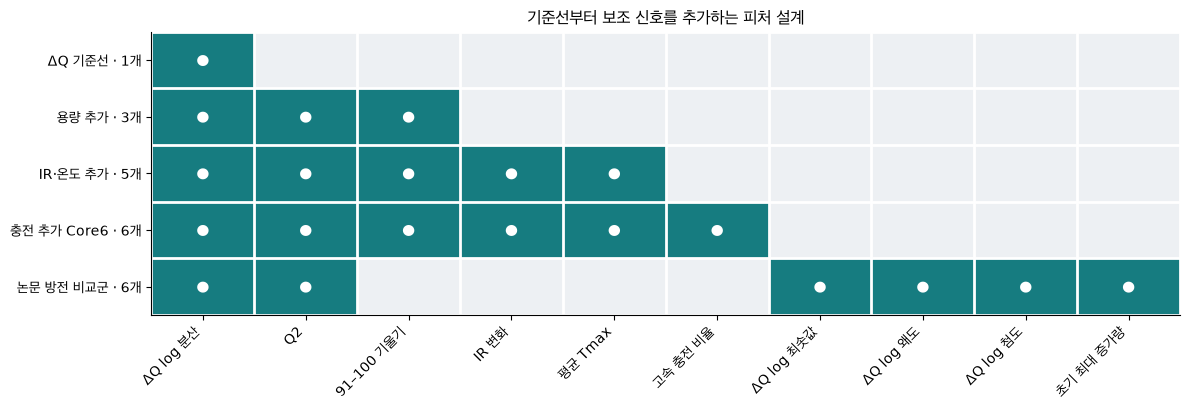

In [14]:
from matplotlib.colors import ListedColormap
order = ['dq_only', 'capacity', 'capacity_ir_temperature', 'core6', 'paper_discharge6']
features = CORE6 + ['dq_logmin', 'dq_logskew', 'dq_logkurtosis', 'q_max_minus_q2']
values = np.array([[int(feature in DESIGN_FAMILIES[family]) for feature in features] for family in order])
row_labels = ['ΔQ 기준선 · 1개', '용량 추가 · 3개', 'IR·온도 추가 · 5개', '충전 추가 Core6 · 6개', '논문 방전 비교군 · 6개']
column_labels = ['ΔQ log 분산', 'Q2', '91–100 기울기', 'IR 변화', '평균 Tmax', '고속 충전 비율',
                 'ΔQ log 최솟값', 'ΔQ log 왜도', 'ΔQ log 첨도', '초기 최대 증가량']
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.imshow(values, cmap=ListedColormap(['#edf0f3', '#167c80']), vmin=0, vmax=1, aspect='auto')
ax.set_yticks(range(len(order)), row_labels)
ax.set_xticks(range(len(features)), column_labels, rotation=45, ha='right')
for i in range(len(order)):
    for j in range(len(features)):
        if values[i, j]:
            ax.text(j, i, '●', color='white', ha='center', va='center', fontsize=11)
ax.set_xticks(np.arange(-.5, len(features), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(order), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', length=0)
ax.set_title('기준선부터 보조 신호를 추가하는 피처 설계')
fig.tight_layout()
fig.savefig(FIGURES / 'fe_family_comparison.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## 9. 타깃·분할·학습 내부 전처리

### 회귀와 log 수명
중간 수명 60셀도 보존하고, 500·1,000사이클 경계로 연속 정보를 잃지 않도록 회귀를 사용한다. B1에는 <500셀 자체가 없어 장·단수명 분류의 학습 범위가 특히 제한된다. 타깃은 `log10(Cycle Life)`, 예측은 `10**y_pred`로 역변환하며 평가는 실제 cycles 단위 MAPE로 수행한다.

### 예측 입력·타깃·분할 정보 분리
cell·batch·정책 그룹은 추적과 분할 정보이며 X에서 제외한다. life는 y로만 사용한다. Knee·후기 기울기·최종 용량·전체 사이클 수·수명으로 정규화한 좌표는 cycle 100에 알 수 없어 제외한다.

### 정책 그룹으로 먼저 분할
Q4의 반복 충전 정책과 태그 집단 차이를 고려해, C1·전환 SOC·C2가 같으면 태그가 달라도 같은 그룹에 둔다. B1 개발 26셀과 Hold-out 10셀의 정책이 겹치지 않게 분할한다. 중앙값 대치와 표준화는 이 분할 이후 학습 fold에서만 fit한다. 피처 선택·튜닝도 같은 범위를 지켜야 한다.

In [15]:
protocol = d.policy.str.extract(r'([\d.]+)C\((\d+)%\)-([\d.]+)C').astype(float)
protocol.columns = ['c1', 'soc_switch', 'c2']
protocol['soc_switch'] /= 100
d = pd.concat([d, protocol], axis=1)
d['c_eff'] = .8 / (d.soc_switch / d.c1 + (.8 - d.soc_switch) / d.c2)
d['newstructure'] = d.policy.str.contains('newstructure', regex=False)
d['policy_group'] = [f'{c1:g}|{soc:g}|{c2:g}' for c1, soc, c2 in zip(d.c1, d.soc_switch, d.c2)]
d['target_log10'] = np.log10(d.life)
assert np.allclose(10**d.target_log10, d.life)

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
B1 = d.loc[d.batch == 'B1'].reset_index(drop=True)
train, valid = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=20261001).split(B1, groups=B1.policy_group))
assert set(B1.iloc[train].policy_group).isdisjoint(B1.iloc[valid].policy_group)
for a, b in GroupKFold(4).split(B1.iloc[train], groups=B1.iloc[train].policy_group):
    assert set(B1.iloc[train].iloc[a].policy_group).isdisjoint(B1.iloc[train].iloc[b].policy_group)
preprocessor = Pipeline([
    ('impute', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True)),
    ('scale', StandardScaler()),
])
X_train = preprocessor.fit_transform(B1.iloc[train][CORE6])
X_valid = preprocessor.transform(B1.iloc[valid][CORE6])
assert preprocessor['scale'].n_samples_seen_ == len(train) == 26
display(pd.Series({'development_cells': len(train), 'holdout_cells': len(valid),
                   'shared_protocols': 0, 'scaler_fit_cells': 26}))

development_cells    26
holdout_cells        10
shared_protocols      0
scaler_fit_cells     26
dtype: int64

여기서는 전처리의 fit 범위만 확인하며 최종 모델을 먼저 선택하지 않는다. 실제 03에서는 각 후보의 내부 CV fold마다 Pipeline을 새로 적합한다. B2/B3의 값으로 중앙값이나 표준화 파라미터를 정하지 않는다.

## 10. 확장 후보와 후속 모델링 입력

### 설계 후보와 확장 탐색 후보를 구분
최초 설계의 Core6와 논문 비교군을 우선한다. 기본 피처와 확장 피처를 포함해 총 73개 후보를 구성했다. 아래 표는 확장 피처의 종류와 목적을 정리한 것이며, 73개 후보를 모두 최종 모델에 사용하지는 않는다.

| 확장 종류 | 생성 목적 | 해석상의 제약 |
|---|---|---|
| 초기 용량 시점·상대값·구간 기울기 | 초기 증가·국소 변화의 표현 방식 비교 | 같은 용량 신호의 강한 중복 가능 |
| IR·온도·충전 시간의 표준편차·기울기·창 차이 | 평균이나 두 시점 차이에 남지 않은 변동 확인 | 작은 B1 표본에서 과적합 가능 |
| ΔQ의 IQR·절댓값 평균·전압별 값·구간 분산 | 변화 곡선의 국소 구조를 다른 통계로 표현 | 여러 전압점은 독립 셀이 아님, 공선성 확인 |
| 정책 수치·태그 | 프로토콜 의존성의 민감도 확인 | 수명 집단 대리 변수 위험, 기본 입력에 자동 포함하지 않음 |

이 파생 후보들의 추가 가치는 EDA에서 모두 확인된 것이 아니다. 여러 표현을 생성한 뒤 학습 내부에서 비교할 수 있도록 구성한 탐색 후보다. 아래 코드는 피처를 직접 생성하며 계산 모듈이나 저장된 피처 테이블을 불러오지 않는다.

In [16]:
ALTERNATIVES = {'dq_summary': ['dq_logabsmin', 'dq_mean', 'dq_skew', 'dq_kurtosis'],
 'capacity': ['q_ratio', 'q_slope'],
 'resistance_temperature': ['ir_mean', 'tavg_mean', 'temp_span'],
 'charging': ['i_mean',
              'i_std',
              'i_peak',
              'charge_time',
              'c1',
              'c2',
              'soc_switch',
              'c_eff'],
 'tag_sensitivity': ['newstructure']}
FORBIDDEN = ['cell',
 'batch',
 'file',
 'index_1based',
 'policy',
 'policy_group',
 'life',
 'life_raw',
 'target_log10',
 'included',
 'exclusion',
 'n_cycles',
 'n_cycle_records',
 'q_end',
 'q_invalid_count',
 'summary_cycle_contiguous',
 'first_below_088',
 'knee',
 'knee_fraction',
 'knee_gain',
 'knee_smoothing_span',
 'early_slope',
 'late_slope',
 'accel_ratio',
 'dq_logstd']
base = list(dict.fromkeys(CORE6 + sum([values for name, values in ALTERNATIVES.items() if name != 'tag_sensitivity'], [])))
rows = []
definitions = {}

In [17]:
for r in d.itertuples():
    c = cells[r.cell]
    s = c['summary']
    x = np.asarray(s['cycle'])
    early = (x >= 2) & (x <= 100)
    xx = x[early]
    q = np.asarray(s['QDischarge'])[early].copy()
    q[(q <= 0) | (q > 1.3)] = np.nan
    row = {k: getattr(r, k) for k in base}
    row.update(cell=r.cell, batch=r.batch, policy=r.policy, policy_group=f'{r.c1:g}|{r.soc_switch:g}|{r.c2:g}', life=r.life, target_log10=np.log10(r.life), policy_newstructure=float(r.newstructure))

    def add(name, value, definition):
        row[name] = float(value)
        definitions[name] = definition

    def at(a, n):
        v = a[xx == n]
        return float(v[0]) if len(v) else np.nan
    for n in [10, 20, 50, 80]:
        val = at(q, n)
        add(f'q_at_{n}', val, f'QDischarge cycle{n}, Ah')
        add(f'q_relative_{n}', val / r.q2, f'QDischarge({n})/QDischarge(2)')
    add('q_growth_2_100', r.q100 / r.q2 - 1, 'QDischarge100/QDischarge2 -1')
    add('q_early_std', np.nanstd(q, ddof=1), 'std QDischarge cycles2..100, Ah')
    slopes = []
    for a, b in [(2, 30), (31, 60), (61, 100)]:
        m = (xx >= a) & (xx <= b)
        z = slope(xx[m], q[m])
        slopes.append(z)
        add(f'q_slope_{a}_{b}', z, f'OLS QDischarge slope cycles{a}..{b}, Ah/cycle')
    add('q_slope_acceleration', slopes[-1] - slopes[0], 'early-window slope61..100 minus slope2..30')
    for source, prefix in [('IR', 'ir'), ('Tmax', 'tmax'), ('Tavg', 'tavg'), ('chargetime', 'charge_minutes')]:
        a = np.asarray(s[source])[early].copy()
        a[(a <= 0) | ~np.isfinite(a)] = np.nan
        add(prefix + '_early_std', np.nanstd(a, ddof=1) if np.isfinite(a).sum() > 1 else np.nan, f'std {source} cycles2..100')
        add(prefix + '_early_slope', slope(xx, a), f'OLS {source} slope cycles2..100')
        v = a[xx <= 10]
        first = np.nanmean(v) if np.isfinite(v).any() else np.nan
        v = a[xx >= 91]
        last = np.nanmean(v) if np.isfinite(v).any() else np.nan
        add(prefix + '_window_change', last - first, f'mean {source} cycles91..100 - mean cycles2..10')
    qc = np.asarray(s['QCharge'])[early].copy()
    qc[(qc <= 0) | (qc > 1.3)] = np.nan
    eff = q / qc
    add('coulombic_eff_mean', np.nanmean(eff), 'mean QDischarge/QCharge cycles2..100')
    add('coulombic_eff_slope', slope(xx, eff), 'OLS QDischarge/QCharge cycles2..100')
    dq = np.asarray(c['dq'])
    v = np.asarray(c['v'])
    assert len(dq) == 1000 and np.isfinite(dq).all()
    add('dq_iqr', np.quantile(dq, 0.75) - np.quantile(dq, 0.25), 'IQR Q100(V)-Q10(V), Ah')
    add('dq_abs_mean', np.mean(np.abs(dq)), 'mean absolute Q100(V)-Q10(V), Ah')
    add('dq_range', np.ptp(dq), 'range Q100(V)-Q10(V), Ah')
    for voltage in [2.2, 2.5, 2.8, 3.0, 3.2, 3.4]:
        add('dq_at_' + str(voltage).replace('.', 'p'), np.interp(voltage, v[::-1], dq[::-1]), f'Q100-Q10 interpolated at {voltage}V, Ah')
    for a, b in [(2, 2.5), (2.5, 3), (3, 3.3), (3.3, 3.5)]:
        z = dq[(v >= a) & (v <= b)]
        tag = f'{a:g}_{b:g}'.replace('.', 'p')
        add('dq_band_logvar_' + tag, np.log10(max(np.var(z, ddof=1), 1e-20)), f'log10 sample variance of deltaQ in {a}..{b}V')
        add('dq_band_mean_' + tag, np.mean(z), f'mean deltaQ in {a}..{b}V, Ah')
    from scipy.stats import skew, kurtosis
    add('dq_logmin', np.log10(abs(np.min(dq))), 'log10 absolute minimum deltaQ, paper')
    add('dq_logskew', np.log10(abs(skew(dq, bias=True))) - 1.5 * np.log10(len(dq)), 'printed paper skewness; standard log-skew minus4.5 for1000 points')
    add('dq_logkurtosis', np.log10(abs(kurtosis(dq, fisher=False, bias=True))), 'log10 Pearson kurtosis deltaQ')
    add('q_max_minus_q2', np.nanmax(q) - r.q2, 'max QDischarge cycles2..100 minus Q2, Ah')
    rows.append(row)

In [18]:
F = pd.DataFrame(rows)
tracking = ['cell', 'batch', 'policy', 'policy_group', 'life', 'target_log10']
all_features = [name for name in F if name not in tracking]
policy_features = ['c1', 'c2', 'soc_switch', 'c_eff', 'policy_newstructure']
feature_families = dict(DESIGN_FAMILIES)
feature_families.update({
    'dq_shape': [name for name in all_features if name.startswith('dq_')],
    'engineered_no_policy': [name for name in all_features if name not in policy_features],
    'engineered_with_policy': all_features,
})
assert F.cell.is_unique and len(F) == 118 and len(all_features) == 73
assert not set(all_features) & set(FORBIDDEN)
assert not np.isinf(F[all_features].to_numpy()).any()
comparison = F[['cell'] + CORE6].merge(core_reference, on='cell', suffixes=('_expanded', '_core'))
for feature in CORE6:
    assert np.allclose(comparison[feature + '_expanded'], comparison[feature + '_core'], equal_nan=True)
display(F[tracking + CORE6].head())
display(pd.DataFrame([{'family': name, 'n_features': len(values)} for name, values in feature_families.items()]))

,cell,batch,policy,policy_group,life,target_log10,dq_logvar,q2,q_slope_last,ir_delta,tmax_mean,i_high
0,B1-C06,B1,4.4C(80%)-4.4C,4.4|0.8|4.4,1074.0,3.031004,-4.178443,1.076127,-0.000023,0.000077,33.020007,0.000000
1,B1-C07,B1,4.8C(80%)-4.8C,4.8|0.8|4.8,636.0,2.803457,-3.768443,1.075836,-0.000062,-0.000022,35.792631,0.000000
2,B1-C08,B1,4.8C(80%)-4.8C,4.8|0.8|4.8,870.0,2.939519,-3.813052,1.093864,-0.000041,0.000091,35.322695,0.000000
3,B1-C10,B1,5.4C(40%)-3.6C,5.4|0.4|3.6,1054.0,3.022841,-4.058949,1.082974,-0.000013,0.000097,35.984934,0.399003
4,B1-C12,B1,5.4C(50%)-3C,5.4|0.5|3,788.0,2.896526,-4.146462,1.053779,-0.000012,0.000075,36.231754,0.479918


,family,n_features
0,dq_only,1
1,capacity,3
2,capacity_ir_temperature,5
3,core6,6
4,paper_discharge6,6
5,dq_shape,25
6,engineered_no_policy,68
7,engineered_with_policy,73


### 03으로 넘기는 입력
모델마다 사용할 피처군을 명시하고 X와 y를 분리한다. 아래의 paper6 파일은 **비교군의 입력 형식**이며 02에서 최종 피처를 확정했다는 뜻은 아니다. 03의 현재 실험은 ΔQ 단일·용량 3개·용량/저항/온도 5개·Core6·논문 방전 6개를 B1 내부 CV에서 비교한다.

최종 판단은 B1 내부 성능, 기준선 대비 추가 가치, 단순성, 정책 외 검증을 함께 검토한다. B2/B3 점수를 보고 후보를 바꾸지 않는다.

In [19]:
for name, features in DESIGN_FAMILIES.items():
    assert not set(features) & set(FORBIDDEN)
    X = F[features]
    y = F.target_log10
    assert X.index.equals(y.index)
F.to_csv(CACHE / 'engineered_features.csv', index=False)
F[tracking + DESIGN_FAMILIES['paper_discharge6']].to_csv(CACHE / 'model_input_paper6.csv', index=False)
np.savez_compressed(CACHE / 'deltaq_curves.npz', cell=F.cell.to_numpy(dtype=str),
                    dq=np.stack([cells[cell]['dq'] for cell in F.cell]))
catalog = {
    'prediction_cycle': 100, 'n_cells': len(F), 'n_numeric_features': len(all_features),
    'base_features': base, 'new_definitions': definitions, 'feature_families': feature_families,
    'missing': F[all_features].isna().sum().to_dict(),
    'rule': 'Per-cell cycle<=100 features; fit imputation/scaling/selection on training folds only',
}
(CACHE / 'feature_catalog.json').write_text(json.dumps(catalog, ensure_ascii=False, indent=2) + '\n')
print('Core6 선정 근거·직접 계산·비교군 구성 완료. 모델 선정과 성능 평가는 03에서 수행.')

Core6 선정 근거·직접 계산·비교군 구성 완료. 모델 선정과 성능 평가는 03에서 수행.


## 참고문헌
Severson et al. (2019). *Data-driven prediction of battery cycle life before capacity degradation*. Nature Energy, 4, 383–391. [DOI](https://doi.org/10.1038/s41560-019-0356-8).

중간 피처 파일은 `.cache`에만 저장한다. 제출 결과는 노트북의 계산 코드·설명·실행 출력이며 `results`의 구조를 늘리지 않는다.